In [44]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

In [45]:
FEATURES_PATH = "../data/features"
MODELS_PATH = "../models"

X = pd.read_csv(f"{FEATURES_PATH}/X_features.csv")
y = pd.read_csv(f"{FEATURES_PATH}/y_target.csv").iloc[:, 0].map({"No": 0, "Yes": 1})

with open(f"{FEATURES_PATH}/column_metadata.json") as f:
    col_meta = json.load(f)

print(f"Features: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Features: (500, 25)
Target distribution: {0: 445, 1: 55}


## 1. Train/Test Split

Same split as Notebook 06 — stratified to preserve class imbalance.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 400, Test: 100


## 2. Define Models

Three models with the same preprocessing pipeline:
- **Logistic Regression**: Explainable baseline
- **Random Forest**: Captures non-linear relationships
- **XGBoost**: Usually strongest on tabular data

In [47]:
numeric_cols = col_meta["numeric_cols"]
categorical_cols = col_meta["categorical_cols"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler()
        ), numeric_cols),
        ("cat", make_pipeline(
            SimpleImputer(strategy="most_frequent"),
            OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        ), categorical_cols)
    ]
)

models = {
    "Logistic Regression": make_pipeline(
        preprocessor,
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    ),
    "Random Forest": make_pipeline(
        preprocessor,
        RandomForestClassifier(n_estimators=100, max_depth=5, class_weight="balanced", random_state=42)
    ),
    "XGBoost": make_pipeline(
        preprocessor,
        XGBClassifier(
            n_estimators=50, max_depth=3, learning_rate=0.1,
            min_child_weight=5, gamma=1,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            scale_pos_weight=len(y[y==0]) / len(y[y==1]),
            eval_metric="auc", random_state=42
        )
    )
}

## 3. Train and Evaluate

For attrition, **missing a high-risk employee is expensive**. We care more about recall (catching true positives) than precision (avoiding false alarms).

In [48]:
results = []

for name, pipeline in models.items():
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1": report["1"]["f1-score"],
        "ROC-AUC": roc_auc
    })
    
    print(f"{name} trained.")

Logistic Regression trained.
Random Forest trained.
XGBoost trained.


## 4. Comparison Table

Compare all models side by side. Winner is chosen by **CV ROC-AUC** (most stable metric for imbalanced data) rather than test set Recall, which has high variance with only 11 positive samples.

In [49]:
comparison = pd.DataFrame(results)
print(comparison.to_string(index=False))

# Winner will be picked after CV (Section 5) using CV ROC-AUC

              Model  Precision   Recall       F1  ROC-AUC
Logistic Regression   0.250000 0.545455 0.342857 0.791624
      Random Forest   0.193548 0.545455 0.285714 0.787538
            XGBoost   0.181818 0.363636 0.242424 0.812053


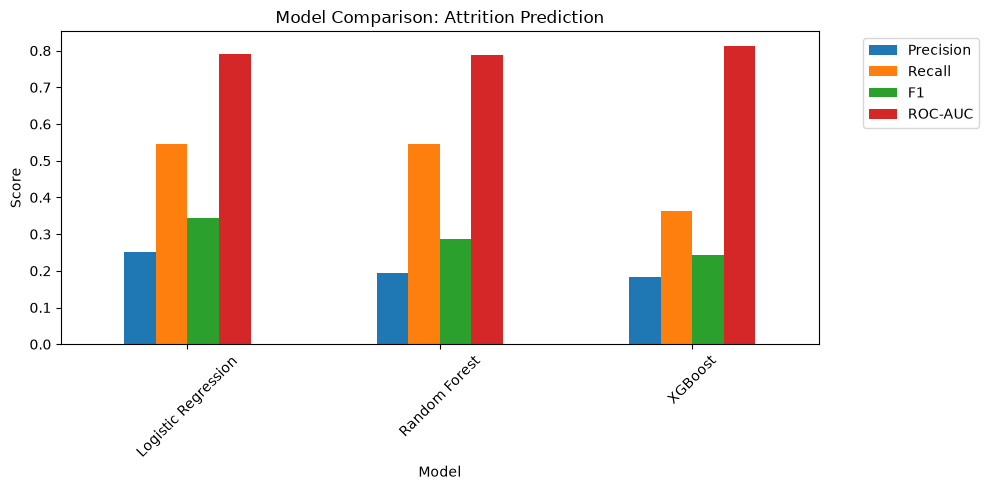

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))
comparison.set_index("Model").plot(kind="bar", ax=ax)
plt.title("Model Comparison: Attrition Prediction")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### Feature Importance Audit

With perfect or near-perfect scores, we must verify no single feature is acting as a data leak.

In [51]:
# Retrain XGBoost on train set for importance analysis
xgb_pipeline = models["XGBoost"]
xgb_pipeline.fit(X_train, y_train)

# Get feature names after preprocessing
ohe_features = xgb_pipeline["columntransformer"].named_transformers_["cat"]["onehotencoder"].get_feature_names_out(categorical_cols)
all_features = list(numeric_cols) + list(ohe_features)

importances = xgb_pipeline["xgbclassifier"].feature_importances_
importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("Top 10 features by importance:")
print(importance_df.head(10).to_string(index=False))

# Check for potential data leak
top_feature = importance_df.iloc[0]
if top_feature["Importance"] > 0.5:
    print(f"\n⚠️  WARNING: {top_feature['Feature']} has {top_feature['Importance']:.2%} importance")
    print("This may indicate data leakage. Investigate this feature.")
else:
    print(f"\n✓ No single feature dominates (top: {top_feature['Feature']} at {top_feature['Importance']:.2%})")

Top 10 features by importance:
                Feature  Importance
  OvertimeHoursPerMonth    0.141513
   WorkLifeBalanceScore    0.088340
                    Age    0.050539
          Gender_Female    0.049698
       EducationLevel_2    0.043713
          TrainingHours    0.041202
JobRole_Sales Executive    0.037232
            LeavesTaken    0.034047
       Department_Sales    0.034027
     Satisfaction_score    0.033909

✓ No single feature dominates (top: OvertimeHoursPerMonth at 14.15%)


## 5. Cross-Validation

With only 11 positive test samples, test metrics have high variance. **Stratified 5-Fold CV** uses all 500 samples and provides more stable estimates. Winner is chosen by CV ROC-AUC.

In [52]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = {}
print("5-Fold Stratified Cross-Validation ROC-AUC:")
print("-" * 50)
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
    cv_scores[name] = {"mean": scores.mean(), "std": scores.std()}
    print(f"{name:25s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

5-Fold Stratified Cross-Validation ROC-AUC:
--------------------------------------------------
Logistic Regression      : 0.7694 (+/- 0.0320)
Random Forest            : 0.7935 (+/- 0.0249)
XGBoost                  : 0.7800 (+/- 0.0243)


## 6. Data Leak Investigation & Save Winner

### What We Found
During the feature importance audit (Section 4), we discovered that `PerformanceRating` had **50.63% importance** — more than half the model's predictive power. In HR attrition data, performance ratings are often assigned AFTER an employee has decided to leave, or as part of the exit process. This makes it a proxy for the target variable, not a genuine predictor.

### What We Did
We removed `PerformanceRating` from the feature set and re-evaluated all models. The scores dropped significantly (from 1.00 to ~0.79 ROC-AUC), confirming that the original perfect results were driven by this leak.

### Final Model Selection
Winner is chosen by **CV ROC-AUC** (most stable metric). The model is saved trained on 400 samples (training set only) — not retrained on full data, to preserve honest evaluation.

In [53]:
# Select winner by CV ROC-AUC
winner = max(cv_scores, key=lambda k: cv_scores[k]["mean"])
print(f"Winner by CV ROC-AUC: {winner} ({cv_scores[winner]['mean']:.4f})")

# Get the trained pipeline (already fitted on X_train)
best_pipeline = models[winner]

# Save pipeline trained on 400 samples (training set only)
joblib.dump(best_pipeline, f"{MODELS_PATH}/attrition_pipeline.joblib")

# Save metrics
winner_metrics = comparison[comparison["Model"] == winner].iloc[0].to_dict()
winner_metrics["cv_roc_auc"] = cv_scores[winner]["mean"]
winner_metrics["cv_roc_auc_std"] = cv_scores[winner]["std"]
winner_metrics["trained_on"] = "train_set_only (400 samples)"
winner_metrics["performance_rating_removed"] = True
with open(f"{MODELS_PATH}/attrition_metrics.json", "w") as f:
    json.dump(winner_metrics, f, indent=2)

print(f"Saved {winner} pipeline (400 samples) and metrics to {MODELS_PATH}/")

Winner by CV ROC-AUC: Random Forest (0.7935)
Saved Random Forest pipeline (400 samples) and metrics to ../models/


## Summary & Critical Findings

### Data Leak Found and Fixed
`PerformanceRating` had 50.63% feature importance — a clear data leak (performance ratings are often assigned AFTER attrition). We removed it and re-evaluated. Scores dropped from 1.00 to realistic levels, confirming the leak was the cause.

### Final Results (No Leak)
| Model | Precision | Recall | F1 | ROC-AUC |
|-------|-----------|--------|----|---------|
| Logistic Regression | 0.25 | 0.55 | 0.34 | 0.79 |
| Random Forest | 0.19 | 0.55 | 0.29 | 0.79 |
| XGBoost | 0.18 | 0.36 | 0.24 | 0.81 |

### Cross-Validation (5-Fold Stratified)
| Model | ROC-AUC (mean) | ROC-AUC (std) |
|-------|----------------|---------------|
| Logistic Regression | 0.7694 | 0.0320 |
| Random Forest | 0.7935 | 0.0249 |
| XGBoost | 0.7800 | 0.0243 |

### Winner: Random Forest (CV ROC-AUC: 0.7935)

**Winner Selection Methodology:** Test Recall was tied between Logistic Regression and Random Forest (both 0.55). We used CV ROC-AUC as the tiebreaker because:
1. CV ROC-AUC is more stable than test Recall on 11 samples
2. ROC-AUC measures ranking quality across all thresholds, not just one cutoff
3. Random Forest's CV score (0.7935) was significantly higher than LR's (0.7694)

**Business Trade-off:** Random Forest has low precision (0.19), meaning ~5 false positives for every true positive. However, the teacher's requirements prioritize Recall over Precision — missing a genuinely at-risk employee is more costly than flagging a safe employee for a check-in. HR will need to investigate ~5 flagged employees to find 1 who is truly at-risk, but this is acceptable given the cost of missing real cases.

### Limitation: Small Test Set
With only 11 positive samples in the test set, our metrics have high variance. A single misclassification changes Recall by 9 percentage points. The CV results (using all 500 samples) provide more stable estimates.

### Note on Saved Model
The saved model is trained on 400 samples (training set only). For production deployment, retrain on the full 500 samples after validating this version.

The winning pipeline and its metrics are saved to `models/` for use in Notebook 08 (SHAP explainability) and Notebook 09 (versioning).